In [1]:
#dataset = https://www.kaggle.com/datasets/erdemtaha/cancer-data

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import kagglehub
from kagglehub import KaggleDatasetAdapter

In [2]:
kagglehub.dataset_download('erdemtaha/cancer-data')

100%|██████████| 48.6k/48.6k [00:00<00:00, 70.4kB/s]

Extracting files...


'C:\\Users\\Lenovo\\.cache\\kagglehub\\datasets\\erdemtaha\\cancer-data\\versions\\1'

In [3]:
df = pd.read_csv(r'C:\\Users\\Lenovo\\.cache\\kagglehub\\datasets\\erdemtaha\\cancer-data\\versions\\1\Cancer_Data.csv')

In [6]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [9]:
df = df.drop(columns = ['id', 'Unnamed: 32'])

In [11]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df.drop(columns = ['diagnosis']))
df_features = pd.DataFrame(scaled_features, columns = df.drop(columns = ['diagnosis']).columns)

In [12]:
x = df.drop(columns = ['diagnosis'])
y = df['diagnosis']

In [14]:
x_train, x_test, y_train, y_test = train_test_split(scaled_features, y, test_size = 0.3, random_state = 42)

In [26]:
model = KNeighborsClassifier(n_neighbors = 9)

In [27]:
model.fit(x_train, y_train)

,n_neighbors,9
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [28]:
predictions = model.predict(x_test)

In [29]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           B       0.97      0.98      0.98       108
           M       0.97      0.95      0.96        63

    accuracy                           0.97       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.97      0.97      0.97       171



<Axes: >

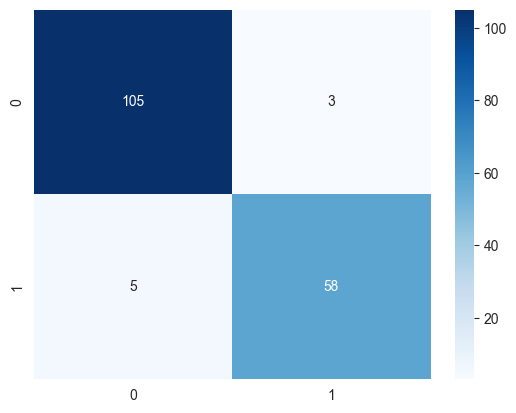

In [22]:
sns.heatmap(confusion_matrix(y_test, predictions), annot = True, fmt = 'd', cmap = 'Blues')

In [24]:
error_rate = []
for i in range(1, 40):
    model2 = KNeighborsClassifier(n_neighbors = i)
    model2.fit(x_train, y_train)
    predictions2 = model2.predict(x_test)
    error_rate.append(np.mean(predictions2 != y_test))

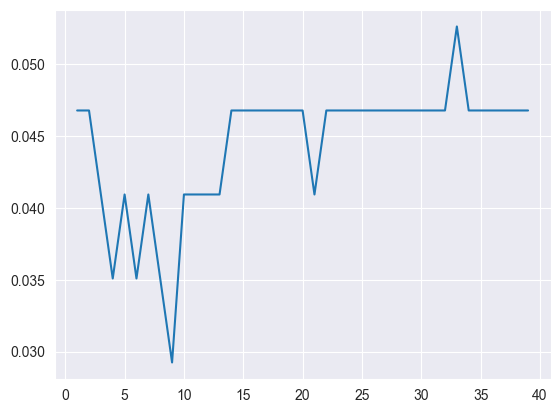

In [25]:
plt.plot(range(1, 40), error_rate)